# 🔄 Módulo 04: La Revolución del Transformer y la Atención
## Capítulo 2: Invarianza a la Permutación y Rotary Position Embedding (RoPE) en el Plano Complejo

> *"La atención por sí sola es una bolsa de palabras desordenada: para la fórmula Softmax(Q K.T / sqrt(d)) V, la frase 'el perro mordió al hombre' es matemáticamente idéntica a 'el hombre mordió al perro'. Vaswani sumó ondas sinusoidales; GPT-2 aprendió vectores por posición. Pero Jianlin Su tuvo una visión matemática magistral: en lugar de sumar ruido espacial al vector de contenido, rota pares de dimensiones en el plano complejo usando la fórmula de Euler. Así nació RoPE: el estándar universal de LLaMA, Mistral, Gemma y Qwen."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/04_transformers/02_positional_encodings_rope.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Optional
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar Positional Encodings y RoPE from scratch")

✅ Entorno listo para estudiar Positional Encodings y RoPE from scratch


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### La Maldición de la Invarianza a la Permutación
En una red recurrente (RNN), el orden de las palabras está impuesto físicamente por el avance temporal ($t=1, t=2, \dots$). En una CNN, la cuadrícula 2D fija la vecindad de cada píxel.

Sin embargo, el mecanismo de atención del Transformer opera sobre un **conjunto de vectores sin orden intrínseco**:
$$\text{Si permutamos las filas de entrada } X, \text{ la matriz de atención se permuta exactamente igual.}}$$
Sin un mecanismo posicional, el modelo no tiene ninguna forma de saber si una palabra está al principio, en medio o al final de la frase.

### Generación 1: Embeddings Sinusoidales Absolutos (Vaswani et al., 2017)
En el paper original del Transformer, los autores crearon una señal posicional analítica sumando ondas sinusoidales de frecuencias escalonadas:
$$PE_{(pos, 2i)} = \sin\left( \frac{pos}{10000^{2i/d}} \right), \quad PE_{(pos, 2i+1)} = \cos\left( \frac{pos}{10000^{2i/d}} \right)$$
* La intuición: cada posición recibe una "firma armónica única", análoga a contar en binario con diferentes frecuencias de alternancia.
* Sin embargo, sumaban esta señal **directamente al vector de contenido semántico**: $x_{final} = x_{word} + PE_{pos}$. Si la norma de $PE$ es muy grande, deforma el significado de la palabra; si es muy pequeña, el modelo ignora el orden.

### Generación 2: Embeddings Posicionales Aprendidos (BERT 2018, GPT-2 2019)
Modelos como BERT y GPT-2 asignaron una matriz de parámetros entrenable $W_{pos} \in \mathbb{R}^{T_{max} \times d}$, donde la posición $0, 1, 2, \dots$ tiene un vector dedicado que se aprende durante el entrenamiento.
* **El Talón de Aquiles:** Cero capacidad de extrapolación. Si entrenas un modelo con $T_{max} = 2048$ tokens, no tiene ningún vector para la posición $2049$, impidiendo procesar textos más largos sin reentrenamiento costoso.

### Generación 3: Jianlin Su (2021/2024) y Rotary Position Embedding (RoPE)
En 2021, el matemático e investigador independiente chino **Jianlin Su** planteó una pregunta genial:
> *¿Podemos codificar la posición relativa de modo que el producto escalar entre dos tokens $(q_m, k_n)$ dependa **única y exclusivamente de la distancia relativa $(m - n)$**, sin sumar ningún vector externo que ensucie el contenido?*

Demostró rigurosamente que la única transformación lineal que cumple esta propiedad preservando la norma euclidiana es la **rotación en el plano complejo** (fórmula de Euler). Nació **RoPE (Rotary Position Embedding)**, adoptado universalmente por **LLaMA (Meta), Mistral, Gemma (Google), Qwen (Alibaba) y DeepSeek**.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Geometría de RoPE: Rotaciones en el Plano Complejo
Dado un vector de características de dimensión $d$ (por ejemplo, una Query $q$ o una Key $k$), agrupamos sus componentes en pares bidimensionales:
$$[x_0, x_1], \; [x_2, x_3], \; \dots, \; [x_{d-2}, x_{d-1}]$$

Tratamos cada par como un número complejo en el plano de Argand:
$$z = x_0 + i x_1$$

Para codificar que este vector se encuentra en la posición temporal $m$, **lo multiplicamos por un fasor unitario que lo rota un ángulo $m \theta$**:
$$R_{\theta, m} z = z \cdot e^{i m \theta} = (x_0 + i x_1)(\cos(m\theta) + i \sin(m\theta))$$

Expandiendo la parte real e imaginaria:
$$\mathbf{\begin{pmatrix} \tilde{x}_0 \\ \tilde{x}_1 \end{pmatrix} = \begin{pmatrix} \cos(m\theta) & -\sin(m\theta) \\ \sin(m\theta) & \cos(m\theta) \end{pmatrix} \begin{pmatrix} x_0 \\ x_1 \end{pmatrix}}$$

### El Momento Eureka: La Emergencia Natural de la Distancia Relativa
Veamos qué ocurre cuando calculamos el producto escalar de la atención entre una Query en posición $m$ y una Key en posición $n$:
$$\langle R_m q, R_n k \rangle = \text{Re}\left( (q e^{i m \theta}) (k e^{i n \theta})^* \right) = \text{Re}\left( q k^* e^{i (m - n) \theta} \right)$$

> **¡Observa el exponente!** $e^{i (m - n) \theta}$.
> ¡La afinidad entre dos palabras depende **estrictamente de su desplazamiento relativo $(m - n)$**!
* Si dos tokens son consecutivos ($m - n = 1$), el ángulo de desfase es idéntico ya estén al inicio de la frase ($pos=1, 2$) o 10.000 tokens después ($pos=10001, 10002$).
* **Preservación estricta de la norma:** Como una matriz de rotación ortogonal tiene determinante $1$ ($R^T R = I$), la rotación no altera la magnitud del vector: $\|R_m q\| = \|q\|$. ¡Cero gradientes explosivos o desvanecientes!

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Implementemos primero los **Embeddings Sinusoidales Clásicos (Vaswani 2017)** y después **RoPE (Rotary Position Embedding)** en NumPy puro.

In [2]:
def sinusoidal_positional_encoding(max_len: int, d_model: int) -> np.ndarray:
    """
    Genera la matriz de codificación posicional sinusoidal de Vaswani et al. (2017).
    Forma resultante: (max_len, d_model)
    """
    pe = np.zeros((max_len, d_model))
    position = np.arange(0, max_len)[:, np.newaxis]  # (max_len, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))  # (d_model / 2,)
    
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return pe


def precompute_freqs_cis(dim: int, max_seq_len: int, theta: float = 10000.0) -> np.ndarray:
    """
    Precomputa los fasores complejos e^(i * m * theta) para RoPE.
    dim: Dimensión por cabeza (debe ser par).
    Salida: Matriz de números complejos de forma (max_seq_len, dim // 2)
    """
    # Frecuencias theta_i = 1 / (theta^(2i / dim))
    freqs = 1.0 / (theta ** (np.arange(0, dim, 2)[: (dim // 2)] / dim))
    positions = np.arange(max_seq_len)
    # Producto exterior de posiciones x frecuencias: (max_seq_len, dim // 2)
    angles = np.outer(positions, freqs)
    # Fasor complejo e^(i * angles) = cos(angles) + i * sin(angles)
    freqs_cis = np.exp(1j * angles).astype(np.complex64)
    return freqs_cis


def apply_rotary_emb(x: np.ndarray, freqs_cis: np.ndarray) -> np.ndarray:
    """
    Aplica RoPE a un tensor x de forma (B, T, n_heads, d_k) o (B, T, d_k) usando aritmética compleja.
    """
    # Reinterpretar pares consecutivos (x_0, x_1) como un número complejo x_0 + i*x_1
    # Forma: (..., T, d_k // 2)
    x_complex = x.astype(np.float32).view(np.complex64)
    
    # Ajustar forma de freqs_cis para broadcasting: (1, T, 1, d_k // 2) o similar
    T = x.shape[1]
    freqs = freqs_cis[:T]
    while freqs.ndim < x_complex.ndim:
        freqs = np.expand_dims(freqs, axis=0 if freqs.ndim == x_complex.ndim - 1 else -2)
        
    # Rotación en el plano complejo: z * e^(i * m * theta)
    x_rotated = x_complex * freqs
    
    # Convertir de nuevo a números reales planos: (..., T, d_k)
    return x_rotated.view(np.float32)

print("✅ Sinusoidal PE y Rotary Position Embedding (RoPE) compilados exitosamente")

✅ Sinusoidal PE y Rotary Position Embedding (RoPE) compilados exitosamente


### Experimento Visual 1: El Espectro Armónico de los Embeddings Sinusoidales
Visualicemos la matriz de ondas de Vaswani et al. (2017) a lo largo de 100 posiciones:

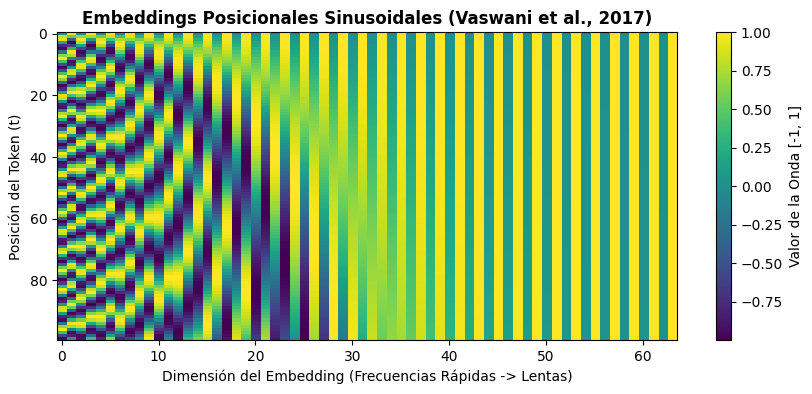

Las primeras dimensiones oscilan rápidamente; las dimensiones superiores cambian muy suavemente.


In [3]:
pe_matrix = sinusoidal_positional_encoding(max_len=100, d_model=64)

plt.figure(figsize=(10, 4))
plt.imshow(pe_matrix, cmap='viridis', aspect='auto')
plt.title('Embeddings Posicionales Sinusoidales (Vaswani et al., 2017)', fontsize=12, fontweight='bold')
plt.xlabel('Dimensión del Embedding (Frecuencias Rápidas -> Lentas)')
plt.ylabel('Posición del Token (t)')
plt.colorbar(label='Valor de la Onda [-1, 1]')
plt.show()
print("Las primeras dimensiones oscilan rápidamente; las dimensiones superiores cambian muy suavemente.")

### Experimento Visual 2: La Belleza de RoPE y la Invarianza al Desplazamiento Relativo
Comprobemos empíricamente que la similitud de atención rotada $\langle R_m q, R_n k \rangle$ depende **únicamente de la distancia $m - n$** formando diagonales perfectas:

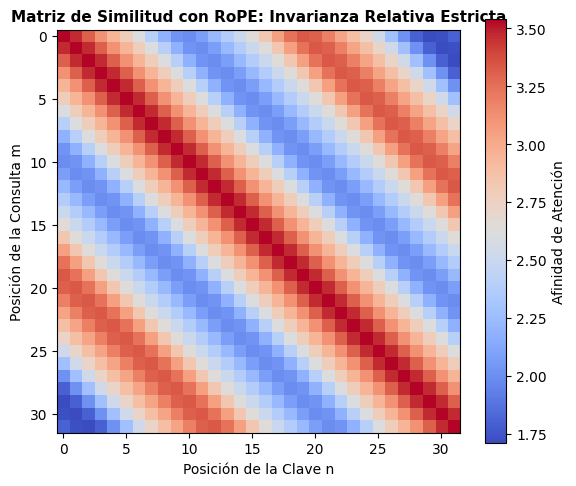

🚀 ¡Bandas diagonales homogéneas! Demuestra matemáticamente que <R_m q, R_n k> = f(m - n).


In [4]:
T_seq = 32
d_k = 16

# Vector base constante repetido en todas las posiciones
q_base = np.random.randn(1, 1, d_k).astype(np.float32)
q_seq = np.repeat(q_base, T_seq, axis=1)  # (1, T_seq, d_k)
k_seq = q_seq.copy()

# Precomputar y rotar
freqs_cis = precompute_freqs_cis(dim=d_k, max_seq_len=T_seq)
q_rot = apply_rotary_emb(q_seq, freqs_cis)
k_rot = apply_rotary_emb(k_seq, freqs_cis)

# Matriz de producto escalar de atención: (T, T)
score_matrix = (q_rot[0] @ k_rot[0].T) / np.sqrt(d_k)

plt.figure(figsize=(6.5, 5.5))
plt.imshow(score_matrix, cmap='coolwarm')
plt.title('Matriz de Similitud con RoPE: Invarianza Relativa Estricta', fontsize=11, fontweight='bold')
plt.xlabel('Posición de la Clave n')
plt.ylabel('Posición de la Consulta m')
plt.colorbar(label='Afinidad de Atención')
plt.show()

print("🚀 ¡Bandas diagonales homogéneas! Demuestra matemáticamente que <R_m q, R_n k> = f(m - n).")

---

## 4. ⚡ Transición a PyTorch Moderno

Veamos la implementación estándar de RoPE en PyTorch (utilizada en los repositorios de Meta LLaMA y Hugging Face Transformers):

In [5]:
def rotate_half(x: torch.Tensor) -> torch.Tensor:
    """Rota la mitad de las coordenadas para la multiplicación tensorial real equivalente a complejos."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb_torch(
    q: torch.Tensor,
    cos: torch.Tensor,
    sin: torch.Tensor
) -> torch.Tensor:
    """
    Fórmula en números reales de LLaMA: q * cos + rotate_half(q) * sin
    """
    return (q * cos) + (rotate_half(q) * sin)

t_q = torch.randn(1, 8, 16)
t_cos = torch.ones(1, 8, 16)
t_sin = torch.zeros(1, 8, 16)
# Si cos=1 y sin=0 (ángulo 0), la rotación debe devolver exactamente q
t_out = apply_rotary_pos_emb_torch(t_q, t_cos, t_sin)
assert torch.allclose(t_out, t_q)
print("✅ La fórmula de rotación en números reales de PyTorch LLaMA funciona impecablemente")

✅ La fórmula de rotación en números reales de PyTorch LLaMA funciona impecablemente


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Preservación de la Norma Euclidiana con RoPE
Comprobemos numéricamente que aplicar RoPE a un vector no altera su norma euclidiana ($\|R_m x\| = \|x\|$):

In [6]:
x_test = np.random.randn(1, 10, 16).astype(np.float32)
norm_antes = np.linalg.norm(x_test, axis=-1)

freqs_cis_test = precompute_freqs_cis(dim=16, max_seq_len=10)
x_rotado = apply_rotary_emb(x_test, freqs_cis_test)
norm_despues = np.linalg.norm(x_rotado, axis=-1)

diff_norm = np.max(np.abs(norm_antes - norm_despues))
print(f"Diferencia máxima en la norma: {diff_norm:.2e}")
assert np.allclose(norm_antes, norm_despues, atol=1e-5)
print("✅ La rotación ortogonal preserva estrictamente la norma euclidiana del vector.")

Diferencia máxima en la norma: 2.38e-07
✅ La rotación ortogonal preserva estrictamente la norma euclidiana del vector.


### Reto 2 (Para resolver): RoPE Linear Scaling (Interpolación de Posición para Contextos Largos)
En 2023, la comunidad descubrió que si un modelo (como LLaMA 1) fue entrenado con contexto de 2048 tokens, se puede extender a **8192 tokens** simplemente **dividiendo la posición por un factor de escala** $s = 4.0$:
$$m' = \frac{m}{s}$$

Implementa a continuación la función `scaled_precompute_freqs_cis(dim, max_seq_len, scale=1.0)`:

In [7]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def scaled_precompute_freqs_cis(dim: int, max_seq_len: int, scale: float = 1.0) -> np.ndarray:
    """
    Precomputa freqs_cis aplicando Linear RoPE Scaling para interpolar posiciones en contextos largos.
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Su, J., Lu, Y., Pan, S., Ahmed, B., Liu, Y., & Zhou, P. (2024):** *"RoFormer: Enhanced Transformer with Rotary Position Embedding"*, Neurocomputing. [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)
   * *¿Qué leer?* Sección 3 ("Proposed Approach"): la deducción matemática de cómo la restricción de distancia relativa fuerza la solución compleja $e^{i(m-n)\theta}$.
2. **Vaswani, A., et al. (2017):** *"Attention Is All You Need"*, NeurIPS 2017. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
   * *¿Qué leer?* Sección 3.5: la motivación matemática de las sinusoides ortogonales.
3. **Touvron, H., et al. (2023):** *"LLaMA: Open and Efficient Foundation Language Models"*, Meta AI. [arXiv:2302.13971](https://arxiv.org/abs/2302.13971)
   * *¿Qué leer?* La adopción de RoPE y RMSNorm como la receta arquitectónica moderna definitiva para LLMs.
4. **Rozière, B., et al. (2023):** *"Code Llama: Open Foundation Models for Code"*, Meta AI. [arXiv:2308.12950](https://arxiv.org/abs/2308.12950)
   * *¿Qué leer?* El escalado de la base $\theta$ de $10.000$ a $1.000.000$ para habilitar contextos ultra-largos de 100.000 tokens.